In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve

# Config
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: '%.3f' % x)
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
sys.path.append(os.getcwd())

import config as cfg
FILE_PATH = cfg.FILE_MATCHES_ELO
print(f"Configuration chargée, source : {FILE_PATH}")

df_raw = pd.read_csv(FILE_PATH, sep=";", parse_dates=["MatchDate"], dayfirst=True)

# Filtre : Big 5 + Récents (> 2006)
target_divs = ['E0', 'F1', 'D1', 'I1', 'SP1']
df = df_raw[
    (df_raw['Division'].isin(target_divs)) &
    (df_raw['MatchDate'].dt.year >= 2006)
].sort_values("MatchDate").reset_index(drop=True)

# Cible
df["Target"] = df["FTResult"].map({'H': 0, 'D': 1, 'A': 2})

# INTELLIGENCE TEMPORELLE (Rolling Stats)
def add_rolling_stats(df, windows=[5]):
    stats_source = [
        "FTHomeGoals", "FTAwayGoals", 
        "HomeShots", "AwayShots", 
        "HomeCorners", "AwayCorners", 
        "HomeFouls", "AwayFouls",
        "HomeYellow", "AwayYellow",
        "HomeRed", "AwayRed",
        "HomeTarget", "AwayTarget",
        "CardsDiff", "GameDominanceIndex", 
        "ShotsDifference", "CornersDifference" 
    ]
    # On vérifie que les colonnes existent
    stats_source = [c for c in stats_source if c in df.columns]

    new_feats = []
    print(f"Calcul des moyennes glissantes (Last{windows})")
    
    for col in stats_source:
        for w in windows:
            # Stats Domicile (Moyenne des 5 derniers matchs à domicile)
            feat_h = f"H_{col}_Last{w}"
            df[feat_h] = df.groupby("HomeTeam")[col].transform(lambda x: x.shift(1).rolling(window=w).mean())
            new_feats.append(feat_h)
            
            # Stats Extérieur 
            feat_a = f"A_{col}_Last{w}"
            df[feat_a] = df.groupby("AwayTeam")[col].transform(lambda x: x.shift(1).rolling(window=w).mean())
            new_feats.append(feat_a)
            
    return df, new_feats

df, technical_feats = add_rolling_stats(df, windows=[5])

# NETTOYAGE ANTI-LEAKAGE 
cols_leak = [
    "FTHome", "FTAway", "FTResult", "HTHome", "HTAway", "HTResult",
    "HomeShots", "AwayShots", "HomeTarget", "AwayTarget",
    "HomeFouls", "AwayFouls", "HomeCorners", "AwayCorners",
    "HomeYellow", "AwayYellow", "HomeRed", "AwayRed",
    "FTHomeGoals", "FTAwayGoals", "CardsDiff", 
    "GameDominanceIndex", "ShotsDifference", "CornersDifference"
]
cols_leak = [c for c in cols_leak if c in df.columns]
df.drop(columns=cols_leak, inplace=True)

# Suppression des lignes incomplètes (Rolling = NaN au début)
cols_mandatory = technical_feats + ["Target", "OddHome", "OddDraw", "OddAway"]
df_model = df.dropna(subset=cols_mandatory).reset_index(drop=True)

print(f"Données prêtes pour RL : {df_model.shape[0]} matchs")
print(f"Variables Techniques : {len(technical_feats)}")

c:\Users\Alban\Documents\IMDS\Projet_5A\Projet_5A_Prediction_matchs\.venv_pred_match\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration chargée, source : C:\Users\Alban\Documents\IMDS\Projet_5A\Donnees\Matches_with_Elo.csv
Calcul des moyennes glissantes (Last[5])
Données prêtes pour RL : 32145 matchs
Variables Techniques : 30


Features Sportives identifiées : 36
V0 : PRÉDICTION MARCHÉ (SUIVRE LE FAVORI)
Fold 1 | Fin: 2013-01-26 | Accuracy Marché: 52.44%
Fold 2 | Fin: 2016-02-03 | Accuracy Marché: 53.24%
Fold 3 | Fin: 2019-02-04 | Accuracy Marché: 55.16%
Fold 4 | Fin: 2022-02-13 | Accuracy Marché: 53.16%
Fold 5 | Fin: 2025-02-26 | Accuracy Marché: 54.13%
ACCURACY MOYENNE MARCHÉ : 53.63%
V1 : REGRESSION LOGISTIQUE AVEC COTES (BENCHMARK)
Training sur 39 variables
Fold 1 | Modèle: 52.38% vs Marché: 52.44% (Delta: -0.06%)
Fold 2 | Modèle: 52.88% vs Marché: 53.24% (Delta: -0.35%)
Fold 3 | Modèle: 54.94% vs Marché: 55.16% (Delta: -0.22%)
Fold 4 | Modèle: 52.96% vs Marché: 53.16% (Delta: -0.21%)
Fold 5 | Modèle: 53.80% vs Marché: 54.13% (Delta: -0.34%)
------------------------------
Accuracy Globale RL (V1)  : 53.39%
Delta moyen vs Marché     : -0.24%

PREUVE : LES POIDS DES COTES SONT MASSIFS (Top 10 Coeffs)
           Feature  Importance
           OddAway       0.310
      EloAdvantage       0.225
           OddH

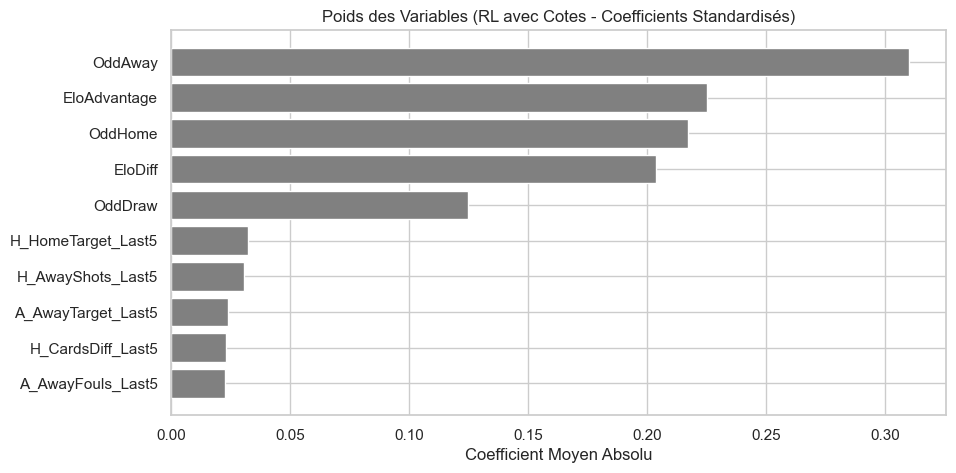

In [2]:
# DÉFINITION DES FEATURES
# Variables Macro
macro_feats = [
    "EloDiff", "EloAdvantage", 
    "Form3Diff", "Form5Diff", 
    "FormMomentumHome", "FormMomentumAway"
]

# Variables Techniques
technical_feats = [c for c in df_model.columns if "_Last5" in c]

# Liste "Aveugle" (Sport uniquement)
features_blind = macro_feats + technical_feats
features_blind = [f for f in features_blind if f in df_model.columns]

print(f"Features Sportives identifiées : {len(features_blind)}")


# V0 : BASELINE MARCHÉ (SANS ML) 
print("V0 : PRÉDICTION MARCHÉ (SUIVRE LE FAVORI)")

tscv = TimeSeriesSplit(n_splits=5)
market_acc_scores = []

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    df_test_fold = df_model.iloc[test_idx]
    
    odds_cols = ["OddHome", "OddDraw", "OddAway"]
    market_preds = df_test_fold[odds_cols].idxmin(axis=1).map({
        "OddHome": 0, "OddDraw": 1, "OddAway": 2
    })
    
    acc = accuracy_score(df_test_fold["Target"], market_preds)
    market_acc_scores.append(acc)
    
    d_date = df_test_fold["MatchDate"].max().date()
    print(f"Fold {fold_id+1} | Fin: {d_date} | Accuracy Marché: {acc:.2%}")

print(f"ACCURACY MOYENNE MARCHÉ : {np.mean(market_acc_scores):.2%}")


# V1 : RÉGRESSION LOGISTIQUE BENCHMARK (AVEC COTES)
print("V1 : REGRESSION LOGISTIQUE AVEC COTES (BENCHMARK)")

# Features FULL (Sport + Cotes)
market_feats = ["OddHome", "OddDraw", "OddAway", "ImpProb_Home", "ImpProb_Draw"]
features_full = features_blind + [f for f in market_feats if f in df_model.columns]

print(f"Training sur {len(features_full)} variables")

# Modèle
model_full = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, random_state=42)

# Boucle
acc_scores_model = []
# Pour stocker l'importance moyenne (moyenne des coeffs absolus)
avg_coefs = np.zeros(len(features_full)) 

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    # Split
    X_train_raw = df_model.iloc[train_idx][features_full]
    y_train = df_model.iloc[train_idx]["Target"]
    X_test_raw = df_model.iloc[test_idx][features_full]
    y_test = df_model.iloc[test_idx]["Target"]
    
    # SCALING 
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)
    
    # Train
    model_full.fit(X_train, y_train)
    
    # Predict
    preds = model_full.predict(X_test)
    
    # Score
    acc_model = accuracy_score(y_test, preds)
    acc_scores_model.append(acc_model)
    
    # Comparaison
    acc_market = market_acc_scores[fold_id]
    print(f"Fold {fold_id+1} | Modèle: {acc_model:.2%} vs Marché: {acc_market:.2%} (Delta: {acc_model - acc_market:+.2%})")
    
    avg_coefs += np.mean(np.abs(model_full.coef_), axis=0)

# Bilan
print("-" * 30)
print(f"Accuracy Globale RL (V1)  : {np.mean(acc_scores_model):.2%}")
print(f"Delta moyen vs Marché     : {np.mean(acc_scores_model) - np.mean(market_acc_scores):+.2%}")

# Preuve Dominance (via les Coefficients)
avg_coefs = avg_coefs / 5 # Moyenne sur les 5 folds
feat_imp = pd.DataFrame({'Feature': features_full, 'Importance': avg_coefs})
top_features = feat_imp.sort_values("Importance", ascending=False).head(10)

print("\nPREUVE : LES POIDS DES COTES SONT MASSIFS (Top 10 Coeffs)")
print(top_features.to_string(index=False))

# Graphique 
plt.figure(figsize=(10, 5))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1], color='gray')
plt.title("Poids des Variables (RL avec Cotes - Coefficients Standardisés)")
plt.xlabel("Coefficient Moyen Absolu")
plt.show()

In [3]:
# V2 : MODÈLE AVEUGLE VS MARCHÉ
print("V2 : RÉGRESSION LOGISTIQUE AVEUGLE (STRATÉGIE UNIFIÉE)")

# Vérification des Features
print(f"Features utilisées : {len(features_blind)} (Macro + Technique)")

# DÉFINITION DES POIDS
# On applique la même logique que pour XGB et RF : léger boost sur le nul
weights = df_model["Target"].map({0: 1.0, 1: 1.1, 2: 1.0})

# Config du Modèle
model_blind = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=2000, 
    random_state=42
)

# Boucle de Validation et Comparaison
tscv = TimeSeriesSplit(n_splits=5)
dfs_results = []
acc_scores_blind = []
market_acc_scores = []

# Variables pour l'explicabilité
last_model = None
feature_names_blind = features_blind

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    # Split Données
    X_train_raw = df_model.iloc[train_idx][features_blind]
    y_train = df_model.iloc[train_idx]["Target"]
    
    # RÉCUPÉRATION DES POIDS POUR CE FOLD 
    w_train = weights.iloc[train_idx]
    
    df_test_fold = df_model.iloc[test_idx].copy()
    X_test_raw = df_test_fold[features_blind]
    
    # SCALING (RL) 
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)
    
    # Train et Predict (AVEC sample_weight)
    model_blind.fit(X_train, y_train, sample_weight=w_train)
    
    # Probabilités
    probs = model_blind.predict_proba(X_test)
    preds = np.argmax(probs, axis=1)
    
    acc_model = accuracy_score(df_test_fold["Target"], preds)
    acc_scores_blind.append(acc_model)
    
    # Benchmark Marché (Comparaison immédiate)
    odds_test = df_test_fold[["OddHome", "OddDraw", "OddAway"]]
    preds_market = odds_test.idxmin(axis=1).map({"OddHome": 0, "OddDraw": 1, "OddAway": 2})
    acc_market = accuracy_score(df_test_fold["Target"], preds_market)
    market_acc_scores.append(acc_market)
    
    # Stockage
    df_test_fold["Prob_H"] = probs[:, 0]
    df_test_fold["Prob_D"] = probs[:, 1]
    df_test_fold["Prob_A"] = probs[:, 2]
    df_test_fold["Pred"] = preds
    dfs_results.append(df_test_fold)
    
    # Logs
    d_date = df_test_fold["MatchDate"].max().date()
    print(f"Fold {fold_id+1} ({d_date}) | Modèle: {acc_model:.2%} vs Marché: {acc_market:.2%} (Delta: {acc_model - acc_market:+.2%})")
    
    # Sauvegarde pour explicabilité 
    if fold_id == 4:
        last_model = model_blind

# Consolidation
df_results = pd.concat(dfs_results)

# Bilan Global
print(f"Accuracy Globale RL Aveugle : {np.mean(acc_scores_blind):.2%}")
print(f"Accuracy Globale Marché      : {np.mean(market_acc_scores):.2%}")
print(f"Écart de Performance         : {np.mean(acc_scores_blind) - np.mean(market_acc_scores):+.2%}")

V2 : RÉGRESSION LOGISTIQUE AVEUGLE (STRATÉGIE UNIFIÉE)
Features utilisées : 36 (Macro + Technique)
Fold 1 (2013-01-26) | Modèle: 51.32% vs Marché: 52.44% (Delta: -1.12%)
Fold 2 (2016-02-03) | Modèle: 51.95% vs Marché: 53.24% (Delta: -1.29%)
Fold 3 (2019-02-04) | Modèle: 53.93% vs Marché: 55.16% (Delta: -1.23%)
Fold 4 (2022-02-13) | Modèle: 52.04% vs Marché: 53.16% (Delta: -1.12%)
Fold 5 (2025-02-26) | Modèle: 53.01% vs Marché: 54.13% (Delta: -1.12%)
Accuracy Globale RL Aveugle : 52.45%
Accuracy Globale Marché      : 53.63%
Écart de Performance         : -1.18%


PERFORMANCE GLOBALE (RL AVEUGLE)
Accuracy      : 52.45%
Log Loss      : 0.9843
Brier Score   : 0.2161 (Home Win)
              precision    recall  f1-score   support

        Home       0.53      0.84      0.65     12063
        Draw       0.28      0.01      0.03      6795
        Away       0.51      0.48      0.50      7927

    accuracy                           0.52     26785
   macro avg       0.44      0.45      0.39     26785
weighted avg       0.46      0.52      0.45     26785



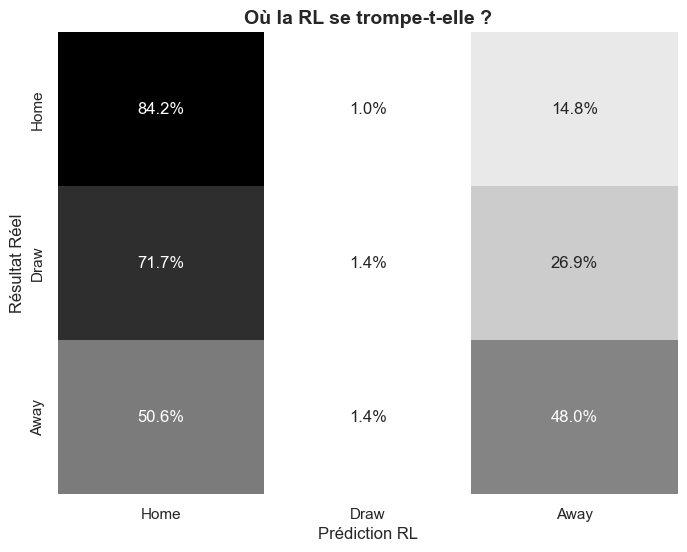

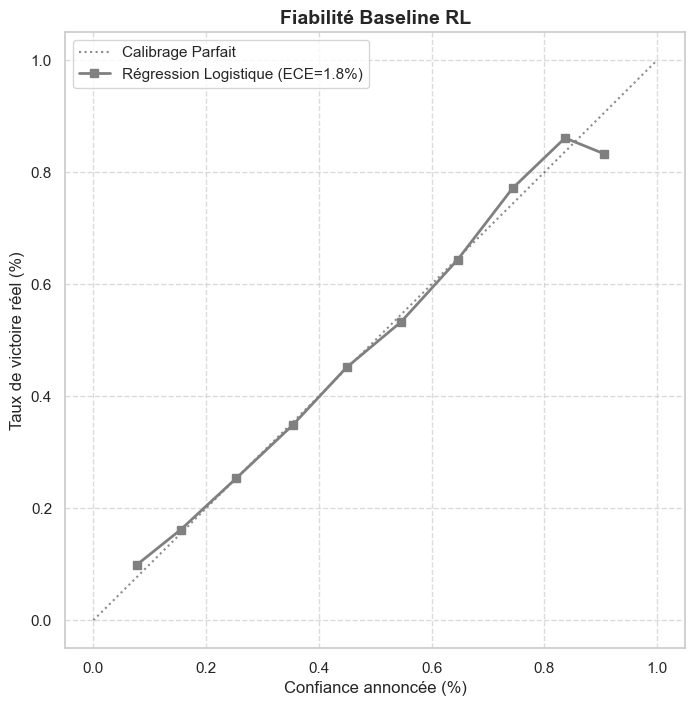

In [4]:
# TABLEAU DE BORD MÉTRIQUES (V2 AVEUGLE)
print("PERFORMANCE GLOBALE (RL AVEUGLE)")

# Calcul des métriques sur l'ensemble concaténé
acc_global = accuracy_score(df_results["Target"], df_results["Pred"])
ll_global = log_loss(df_results["Target"], df_results[["Prob_H", "Prob_D", "Prob_A"]])
y_true_home = (df_results["Target"] == 0).astype(int)
brier = brier_score_loss(y_true_home, df_results["Prob_H"])

print(f"Accuracy      : {acc_global:.2%}")
print(f"Log Loss      : {ll_global:.4f}")
print(f"Brier Score   : {brier:.4f} (Home Win)")
print(classification_report(df_results["Target"], df_results["Pred"], target_names=["Home", "Draw", "Away"]))

# MATRICE DE CONFUSION
plt.figure(figsize=(8, 6))
cm_norm = confusion_matrix(df_results["Target"], df_results["Pred"], normalize='true')

sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Greys", cbar=False, 
            xticklabels=["Home", "Draw", "Away"],
            yticklabels=["Home", "Draw", "Away"])

plt.title("Où la RL se trompe-t-elle ?", fontsize=14, fontweight='bold')
plt.ylabel("Résultat Réel")
plt.xlabel("Prédiction RL")
plt.show()

# COURBE DE CALIBRATION 
prob_true, prob_pred = calibration_curve(y_true_home, df_results["Prob_H"], n_bins=10, strategy='uniform')
ece = np.mean(np.abs(prob_pred - prob_true))

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k:", label="Calibrage Parfait", alpha=0.5)
plt.plot(prob_pred, prob_true, "s-", color="gray", label=f"Régression Logistique (ECE={ece:.1%})", linewidth=2)

plt.xlabel("Confiance annoncée (%)")
plt.ylabel("Taux de victoire réel (%)")
plt.title("Fiabilité Baseline RL", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

GÉNÉRATION DE LA LEARNING CURVE


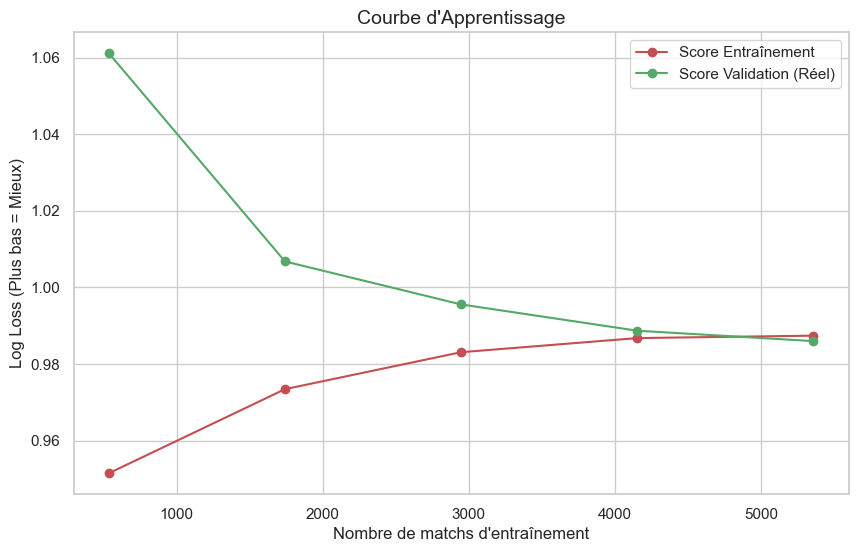

In [5]:
# DIAGNOSTIC : COURBE D'APPRENTISSAGE (LEARNING CURVE) 
from sklearn.model_selection import learning_curve

print("GÉNÉRATION DE LA LEARNING CURVE")

def plot_learning_curve_custom(estimator, X, y, title):
    # TimeSeriesSplit pour respecter la chronologie
    cv = TimeSeriesSplit(n_splits=5)
    
    # Calcul 
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, 
        cv=cv, 
        n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), 
        scoring='neg_log_loss' 
    )
    
    # Conversion en positif
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score Entraînement")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score Validation (Réel)")
    
    plt.title(title, fontsize=14)
    plt.xlabel("Nombre de matchs d'entraînement")
    plt.ylabel("Log Loss (Plus bas = Mieux)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Préparation des données
if 'model_blind' in locals():
    plot_learning_curve_custom(model_blind, df_model[features_blind], df_model["Target"], "Courbe d'Apprentissage")

EXPLICABILITÉ (POIDS DU MODÈLE)


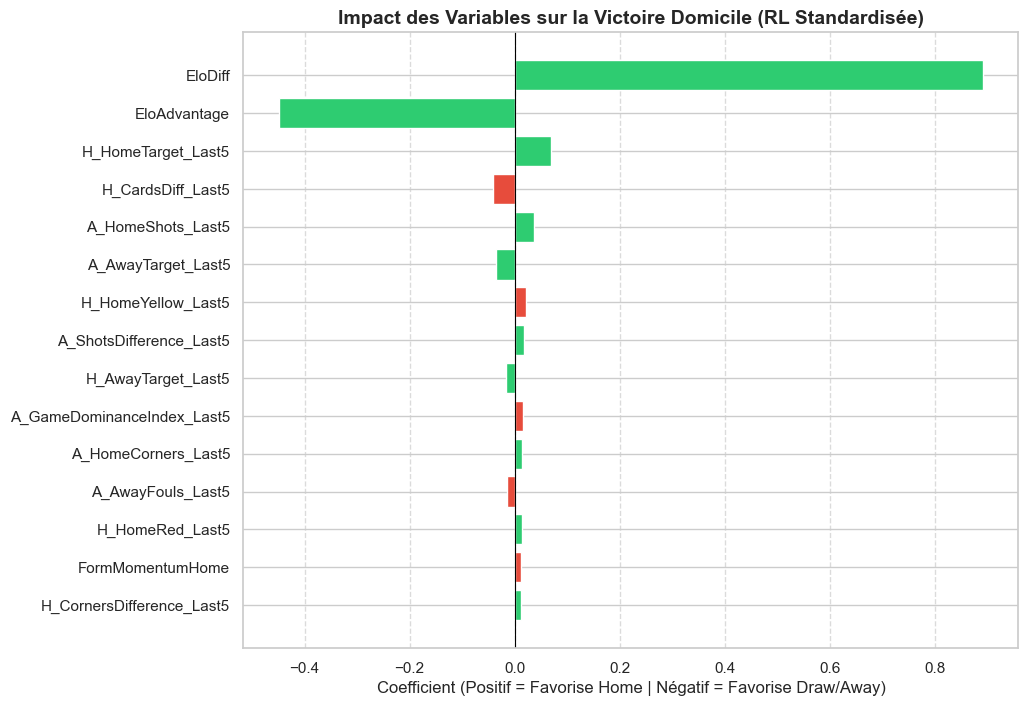

In [6]:
# EXPLICABILITÉ (Coefficients)
print("EXPLICABILITÉ (POIDS DU MODÈLE)")

# Récupération des Coeffs pour la classe "Home Win" (Index 0)
coefs_home = last_model.coef_[0] 

# Organisation des données
df_coefs = pd.DataFrame({
    "Feature": feature_names_blind,
    "Coefficient": coefs_home,
    "Abs_Coef": np.abs(coefs_home) # Pour trier par magnitude
})

# Sélection du Top 15
top_coefs = df_coefs.sort_values("Abs_Coef", ascending=False).head(15)

# Graphique Directionnel
plt.figure(figsize=(10, 8))
# Couleur : Vert si le coefficient favorise la victoire à domicile, Rouge s'il la défavorise
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_coefs["Coefficient"]]

plt.barh(top_coefs["Feature"][::-1], top_coefs["Coefficient"][::-1], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Impact des Variables sur la Victoire Domicile (RL Standardisée)", fontsize=14, fontweight='bold')
plt.xlabel("Coefficient (Positif = Favorise Home | Négatif = Favorise Draw/Away)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [7]:
# ANALYSE FINANCIÈRE et ROI 
print("ANALYSE DE RENTABILITÉ (MODELE AVEUGLE)")

# Calcul de la "Value" détectée par le modèle
# Value = (Probabilité Modèle * Cote Bookmaker) - 1
df_results["Value_H"] = (df_results["Prob_H"] * df_results["OddHome"]) - 1
df_results["Value_D"] = (df_results["Prob_D"] * df_results["OddDraw"]) - 1
df_results["Value_A"] = (df_results["Prob_A"] * df_results["OddAway"]) - 1

# Simulation de Stratégies (Impact de la sélectivité)
thresholds = [0.00, 0.05, 0.10, 0.15, 0.20]
roi_data = []

print("Simulation des paris (Mise fixe = 1 unité) :")
for th in thresholds:
    # On cherche la meilleure Value du match
    max_vals = df_results[["Value_H", "Value_D", "Value_A"]].max(axis=1)
    best_idxs = df_results[["Value_H", "Value_D", "Value_A"]].idxmax(axis=1)
    
    # On filtre : on ne parie que si la Value > Seuil
    mask_bet = max_vals > th
    bets = df_results[mask_bet].copy()
    
    if len(bets) > 0:
        # Calcul du profit
        rewards = []
        for idx, row in bets.iterrows():
            chosen = best_idxs[idx] # ex: "Value_H"
            
            if chosen == "Value_H":
                profit = (row["OddHome"] - 1) if row["Target"] == 0 else -1
            elif chosen == "Value_D":
                profit = (row["OddDraw"] - 1) if row["Target"] == 1 else -1
            else: # Value_A
                profit = (row["OddAway"] - 1) if row["Target"] == 2 else -1
            rewards.append(profit)
            
        total_profit = sum(rewards)
        roi = (total_profit / len(rewards)) * 100
        
        roi_data.append({
            "Seuil Value >": f"{th:.0%}",
            "Nb Paris": len(rewards),
            "ROI": f"{roi:.2f}%",
            "Profit Total": f"{total_profit:.1f}u"
        })
    else:
        roi_data.append({"Seuil Value >": f"{th:.0%}", "Nb Paris": 0, "ROI": "0.00%", "Profit Total": "0"})

# Affichage propre
res_roi = pd.DataFrame(roi_data)
print(res_roi.to_string(index=False))

ANALYSE DE RENTABILITÉ (MODELE AVEUGLE)
Simulation des paris (Mise fixe = 1 unité) :
Seuil Value >  Nb Paris     ROI Profit Total
           0%     23993  -7.05%     -1692.6u
           5%     18205  -7.74%     -1409.1u
          10%     12786  -7.70%      -984.7u
          15%      8756  -9.12%      -798.1u
          20%      5935 -12.49%      -741.3u


In [8]:
# PROFILAGE DES ERREURS (PAR COTE)
print("OÙ GAGNE-T-ON ? (FOCUS VICTOIRE DOMICILE)")

# On découpe les cotes en tranches (Bins)
bins = [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
labels = ["Ultra Favori (1.0-1.5)", "Favori (1.5-2.0)", "Outsider (2.0-3.0)", "Gros Outsider (3.0-5.0)", "Longshot (5.0+)"]

df_results["Cote_Bin"] = pd.cut(df_results["OddHome"], bins=bins, labels=labels)

# On analyse uniquement les paris "Home Win" pris avec une Value > 5%
mask_home_bet = df_results["Value_H"] > 0.05
df_bets_home = df_results[mask_home_bet].copy()

if len(df_bets_home) > 0:
    # Agrégation par tranche
    profiling = df_bets_home.groupby("Cote_Bin", observed=False).apply(
        lambda x: pd.Series({
            "Nb Paris": len(x),
            "Win Rate Réel": (x["Target"] == 0).mean(),
            "Cote Moyenne": x["OddHome"].mean(),
            "Profit": (x[x["Target"]==0]["OddHome"] - 1).sum() - len(x[x["Target"]!=0])
        })
    )
    
    profiling["ROI"] = (profiling["Profit"] / profiling["Nb Paris"]) * 100
    
    print(profiling[["Nb Paris", "Win Rate Réel", "Cote Moyenne", "Profit", "ROI"]])
else:
    print("Pas assez de paris Home pour profiler")

OÙ GAGNE-T-ON ? (FOCUS VICTOIRE DOMICILE)
                         Nb Paris  Win Rate Réel  Cote Moyenne   Profit    ROI
Cote_Bin                                                                      
Ultra Favori (1.0-1.5)    166.000          0.741         1.409    6.040  3.639
Favori (1.5-2.0)         1104.000          0.550         1.807  -13.170 -1.193
Outsider (2.0-3.0)       2914.000          0.383         2.456 -214.170 -7.350
Gros Outsider (3.0-5.0)  1772.000          0.245         3.803 -152.510 -8.607
Longshot (5.0+)           846.000          0.144         6.886  -32.980 -3.898
